In [4]:
import numpy as np
import random
import matplotlib.pyplot as plt
import dask
from dask import delayed
from dask import bag as db
from sklearn.cluster import KMeans
import time

random.seed(42)

from sklearn.datasets import make_blobs # for local cluster generation only

In [5]:
# import the dask distributed client
from dask.distributed import Client

# instantiate the client by providing 
# the address:port of the scheduler
client = Client('dask-scheduler:8786')

# inspect the client
client

<Client: 'tcp://172.19.0.2:8786' processes=1 threads=1, memory=488.28 MiB>

In [6]:
data = make_blobs(n_samples=500, n_features=2, centers=4, random_state=42)
samples = data[0]

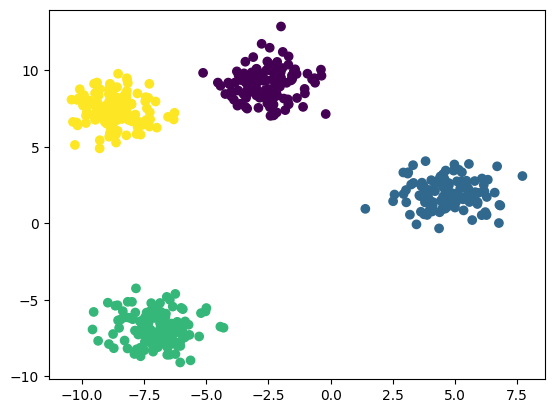

In [7]:
plt.scatter(samples[:,0], samples[:, 1], c=data[1])

In [8]:
X = db.from_sequence(data[0], npartitions=4)
client.persist(X) # (per partition) bc used at every iteration
x = data[0]
c = np.array([[0,0], [1, 1]])
centroids = c
dist_comp_times=0
min_dist_comp_times=0

In [ ]:
class kmeans_parallel(): 
    def __init__(self, k, l):
        self.k = k
        self.l = l
        self.centroids = []

    def compute_all_distances(self, X): 
        centroids_arr = np.vstack(self.centroids)
        d2 = X.map(lambda x: np.linalg.norm(x - centroids_arr, axis=1) ** 2)
        global dist_comp_times 
        dist_comp_times=dist_comp_times+1
        return d2

    def compute_min_distances(self, X, distances=None):  
        if distances is None:
            distances= self.compute_all_distances(X)
        global min_dist_comp_times 
        min_dist_comp_times=min_dist_comp_times+1
        return distances.map(np.min)
 
    def cost_function(self, X, min_distances=None):
        if min_distances is None:
            min_distances= self.compute_min_distances(X)
        return min_distances.sum() 

    def compute_probabilities(self, X, l, distances=None, min_distances=None, cost=None):
        centroids_arr = np.vstack(self.centroids)
        if distances is None:
            d2 = self.compute_all_distances(X)
        else: d2=distances
        if min_distances is None:
            min_d2 = self.compute_min_distances(X, distances=d2) 
        else: min_d2=min_distances
        if cost is None:
            cost = self.cost_function(X, min_distances=min_d2)
        prob = min_d2.map(lambda d: min(1.0, d * l / cost))
        return prob
    
    def compute_weigths(self, distances=None):
        centroids_arr = np.vstack(self.centroids)
        if distances is None:
            distances_from_centroids=self.compute_all_distances(X)
        else: distances_from_centroids = distances
        closer_centers_idxs = distances_from_centroids.map(lambda x: np.argmin(x))
        return closer_centers_idxs.frequencies()

    def compute_starting_centroids(self, X, alpha=1, l=1):
        import dask
        import dask.bag as db
        import random
        from sklearn.cluster import KMeans

        ######################################################
        # STEP 1
        initial_centroid = X.filter(lambda x: random.random() < 0.1).take(1)[0] 
        initial_centroid = np.asarray(initial_centroid).reshape(1, -1)
        self.centroids.append(initial_centroid)

        c0 = initial_centroid[0]
        state = X.map(lambda x: (np.linalg.norm(x - c0) ** 2, 0))
        state = dask.persist(state)[0] 

        ################################################
        # STEP 2
        psi = state.map(lambda t: t[0]).sum().compute()

        #####################################################
        # STEP 3
        max_iter = int(round(alpha * np.log(psi)))
        print("Number of planned iterations:", max_iter)

        for _ in range(max_iter):
            cost = state.map(lambda t: t[0]).sum().compute()
            probs = state.map(lambda t: min(1.0, t[0] * l / cost))

            paired = db.zip(X, probs)
            sample = (
                paired.filter(lambda t: np.random.uniform() < t[1])
                      .map(lambda t: t[0])
            ).compute()

            if not sample:
                continue

            start_idx = len(self.centroids)
            new_centroids_arr = np.vstack([np.asarray(s).reshape(1, -1) for s in sample])
            
            for s in sample:
                self.centroids.append(np.asarray(s).reshape(1, -1))

            # UPDATE STATE: compute distances ONLY to the newly added centroids
            def update_state(pack, new_arr=new_centroids_arr, s_idx=start_idx):
                x, (curr_min_dist, curr_idx) = pack
                dists_to_new = np.linalg.norm(x - new_arr, axis=1) ** 2
                min_new_idx_relative = int(np.argmin(dists_to_new))
                min_new_dist = dists_to_new[min_new_idx_relative]
                
                if min_new_dist < curr_min_dist:
                    return (min_new_dist, s_idx + min_new_idx_relative)
                else:
                    return (curr_min_dist, curr_idx)

            state = db.zip(X, state).map(update_state)
            state = dask.persist(state)[0]

        ###################################################
        # STEP 7
        # Extract weights directly from the optimally tracked state
        counts = state.map(lambda t: t[1]).frequencies().compute()
        weights = np.zeros(len(self.centroids))
        
        for center_idx, count in counts:
            weights[center_idx] = count

        centroids_weights = weights 

        ###################################################
        # STEP 8 using scikit kmeans 
        kmeans = KMeans(n_clusters=self.k)
        kmeans.fit(np.vstack(self.centroids), sample_weight=centroids_weights)
        self.starting_centroids = kmeans.cluster_centers_

        # ONLY STORED FOR ANALYSIS (DAG GRAPH)
        self.min_dists = state.map(lambda t: t[0])

    def fit(self, X, max_iter=100, tol=1e-4):              
        for _ in range(max_iter):
            centroids_arr = np.vstack(self.starting_centroids)
            
            # Map each point to its closest centroid: (cluster_index, point)
            mapped = X.map(lambda x: (int(np.argmin(np.linalg.norm(x - centroids_arr, axis=1))), np.array(x)))
            
            # Group by cluster index and compute the average of the points
            reduced = mapped.groupby(lambda t: t[0]) \
                            .map(lambda g: (g[0], np.mean([item[1] for item in g[1]], axis=0))) \
                            .compute()
            
            # Update the centroids with the new computed averages
            new_centroids = np.copy(centroids_arr)
            for cluster_idx, p_mean in reduced:
                new_centroids[cluster_idx] = p_mean
            
            # Check for convergence 
            if np.linalg.norm(new_centroids - centroids_arr) < tol:
                self.final_centroids = new_centroids
                break
                
            

    def classify(self, X):
        centroids_arr = np.vstack(self.final_centroids)
        # Returns a Dask bag mapping each point to its closest cluster index
        return X.map(lambda x: int(np.argmin(np.linalg.norm(x - centroids_arr, axis=1))))

In [16]:
t1=time.time()
clf = kmeans_parallel(k=4, l=1)
clf.compute_starting_centroids(X)
clf.fit(X)
t2=time.time()
print("All distances computed in total", dist_comp_times, "times")
print("Min distances from centroids computed in total", min_dist_comp_times, "times")
print(f"Time elapsed: {t2-t1:.2f} s")
dist_comp_times=0
min_dist_comp_times=0

Number of planned iterations: 11
All distances computed in total 0 times
Min distances from centroids computed in total 0 times
Time elapsed: 37.41 s


In [11]:
21+1

22

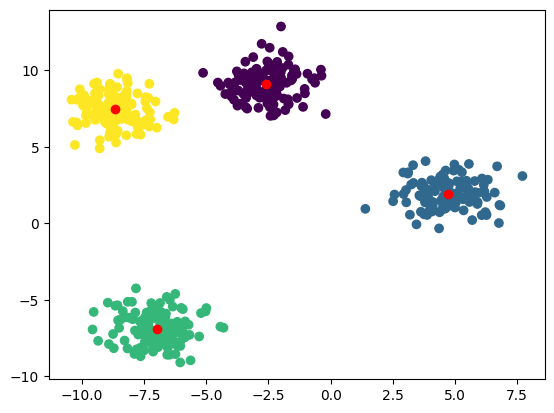

In [12]:
plt.scatter(samples[:,0], samples[:, 1], c=data[1])
plt.scatter(clf.final_centroids[:,0], clf.final_centroids[:,1], c="red")

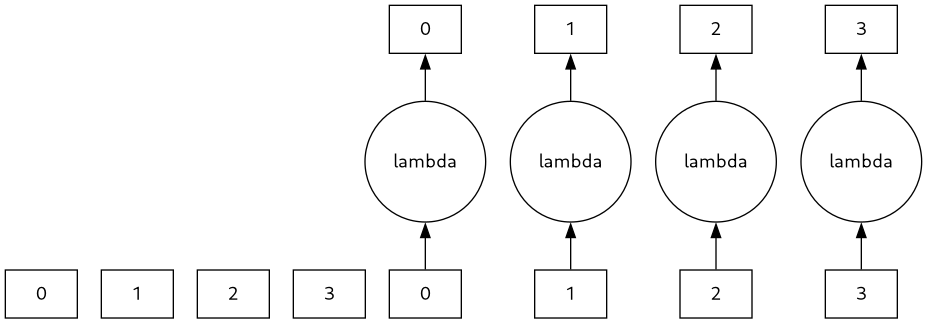

In [13]:
dask.visualize(clf.dists, clf.min_dists, clf.probs, optimize_graph=False, filename='dag_optimized.png')

In [14]:
# TODO: implement the rest of k means|| (ie, do standard k means with these initial centroids - 
# reuse these functions + assign point to closest centroid + update centroids + set a convergence criterion)